# Machine Learning-Based Multi-Asset Trading Strategy

# Machine Learning-Based Multi-Asset Trading Strategy

## Overview
This project develops a machine learning-driven trading strategy using technical indicators to predict short-term price movements across multiple equities.

A Random Forest classifier is trained on engineered features, and predictions are translated into trading signals. Strategy performance is evaluated through backtesting with transaction cost modeling.

In [ ]:
%pip install yfinance scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

## Data Collection

Historical price data is collected using the yfinance API. The dataset includes OHLCV data for multiple large-cap equities.

In [ ]:
def load_stock_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end)

    if df.empty:
        raise ValueError(f"No data returned for {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df.dropna(inplace=True)

    return df

## Feature Engineering

Technical indicators are constructed to capture price trends, momentum, and volatility:

- Returns & Log Returns
- Moving Averages (10, 50)
- Volatility
- Momentum
- RSI (Relative Strength Index)
- Z-score
- Rolling Sharpe Ratio

In [7]:
def add_features(df):
    df = df.copy()

    df["returns"] = df["Close"].pct_change()
    df["log_returns"] = np.log(df["Close"] / df["Close"].shift(1))

    df["ma_10"] = df["Close"].rolling(10).mean()
    df["ma_50"] = df["Close"].rolling(50).mean()

    df["volatility"] = df["returns"].rolling(10).std()
    df["momentum_10"] = df["Close"] - df["Close"].shift(10)

    delta = df["Close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df["rsi"] = 100 - (100 / (1 + rs))

    rolling_mean = df["Close"].rolling(20).mean()
    rolling_std = df["Close"].rolling(20).std()
    df["z_score"] = (df["Close"] - rolling_mean) / rolling_std

    df["sharpe_10"] = (
        df["returns"].rolling(10).mean() /
        df["returns"].rolling(10).std()
    )

    df.dropna(inplace=True)

    return df

## Model & Trading Strategy

A Random Forest classifier is trained to predict the direction of next-day returns.

Predictions are converted into trading signals:
- 1 → Long position
- 0 → No position

A backtesting framework evaluates performance, including transaction costs.

[*********************100%***********************]  1 of 1 completed


Processing NOW...


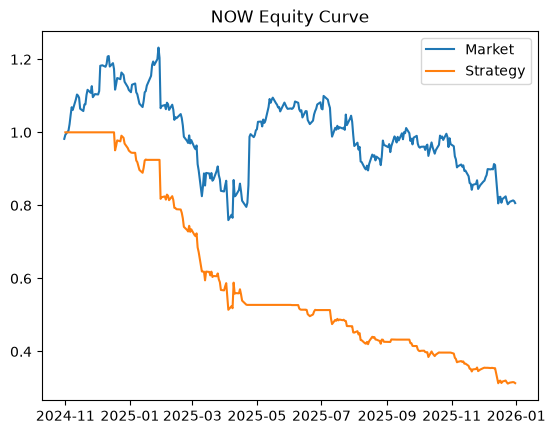

[*********************100%***********************]  1 of 1 completed


Processing MSFT...


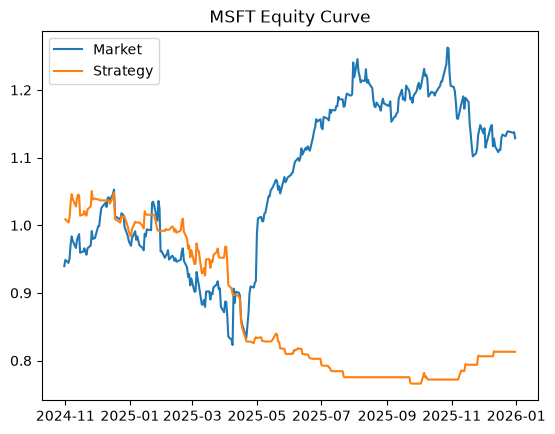

[*********************100%***********************]  1 of 1 completed


Processing NVDA...


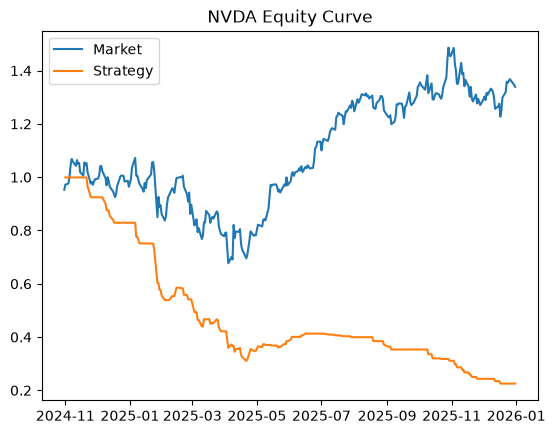

[*********************100%***********************]  1 of 1 completed


Processing ARM...


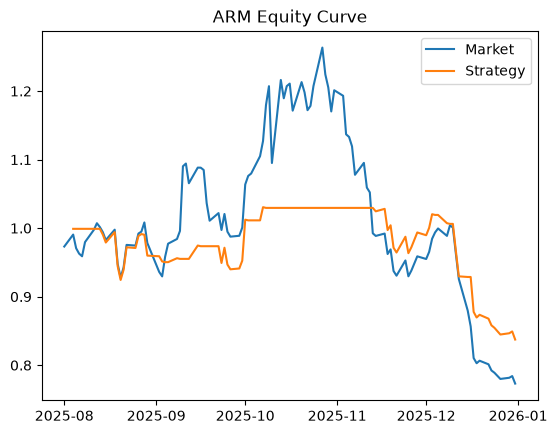

[*********************100%***********************]  1 of 1 completed


Processing HOOD...


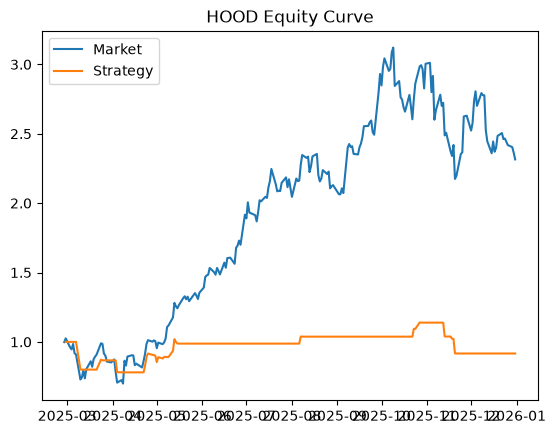

In [8]:
tickers = ["NOW", "MSFT", "NVDA", "ARM", "HOOD"]
results = []

for ticker in tickers:
    print(f"\nProcessing {ticker}...")

    df = load_stock_data(ticker, "2020-01-01", "2026-01-01")
    df = add_features(df)

    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
    df.dropna(inplace=True)

    feature_cols = [
        "returns", "log_returns",
        "ma_10", "ma_50",
        "volatility",
        "momentum_10",
        "rsi",
        "z_score",
        "sharpe_10"
    ]

    X = df[feature_cols]
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Strategy
    df_test = df.iloc[split:].copy()
    df_test["prediction"] = y_pred
    df_test["strategy_returns"] = df_test["returns"] * df_test["prediction"]

    cost = 0.001
    df_test["trades"] = df_test["prediction"].diff().abs()
    df_test["strategy_returns"] -= df_test["trades"] * cost

    df_test["cum_market"] = (1 + df_test["returns"]).cumprod()
    df_test["cum_strategy"] = (1 + df_test["strategy_returns"]).cumprod()

    plt.figure()
    plt.plot(df_test.index, df_test["cum_market"], label="Market")
    plt.plot(df_test.index, df_test["cum_strategy"], label="Strategy")
    plt.title(f"{ticker} Equity Curve")
    plt.legend()
    plt.show()

    sharpe = df_test["strategy_returns"].mean() / df_test["strategy_returns"].std()

    results.append({
        "ticker": ticker,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "sharpe": sharpe
    })

## Results

Strategy performance is evaluated across multiple assets using classification metrics and Sharpe ratio.

### Key Insights

- Model performance varies significantly across different equities, indicating that a single strategy may not generalize well across all assets.
- Momentum and trend-based indicators (e.g., moving averages, RSI) appear to contribute most to predictive performance.
- Transaction costs have a noticeable negative impact on profitability, especially for frequently traded signals.
- While the strategy shows periods of outperformance, it does not consistently beat the market benchmark across all assets.

In [4]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="sharpe", ascending=False)

results_df

,ticker,accuracy,precision,recall,baseline_acc,model_return,market_return,sharpe
4,HOOD,0.488263,0.695652,0.135593,0.553991,-0.029452,1.076274,-0.006103
1,MSFT,0.496575,0.553571,0.389937,0.544521,-0.197596,0.154597,-0.084743
3,ARM,0.575472,0.551020,0.540000,0.471698,-0.165255,-0.213523,-0.103810
0,NOW,0.486301,0.487342,0.527397,0.500000,-1.104550,-0.128185,-0.198614
2,NVDA,0.486301,0.523810,0.285714,0.527397,-1.422093,0.425548,-0.237346


## Conclusion

This project demonstrates how machine learning models can be applied to financial time series to generate systematic trading strategies.

While results show potential, further improvements such as feature selection, hyperparameter tuning, and more robust backtesting methods are required for production-level deployment.